Dissipation vs time for the Sedov test: RICH vs analytic vs shock finder.
Data comes from `scripts/sedov_dissipation_scan.py`; rerun that to refresh, tune plots here.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import unyt

import richio, dev

## Load table

In [2]:
base = "/zfsstore/user/hey4/rich_tde/data/processed/sedov_dissipation"
# Dataset: uncomment one (produced by scripts/sedov_dissipation_scan.py)
# table_path = f"{base}/Sedov3DSchaal15/sedov_dissipation.txt"  # 125k cells, E=1
# table_path = f"{base}/Sedov3DSchaal15+/sedov_dissipation.txt"  # 125k cells, E=1, longer run (to snap 332)
# table_path = f"{base}/Sedov3DSpringel10/sedov_dissipation.txt"  # 262k cells, E=1
# table_path = f"{base}/Springel10+/sedov_dissipation.txt"  # 262k cells, E=1, longer run (to snap 448)
table_path = f"{base}/Sedov3D/sedov_dissipation.txt"  # 5M cells, E~3347, hot ambient

# unyt.loadtxt can't parse code_* units without richio's registry, so load by hand:
# column names come from the 'columns:' header line, units from the last comment line.
reg = richio.units.get_unit("Time").registry
comments = [l for l in open(table_path) if l.startswith("#")]
names = next(l for l in comments if "columns:" in l).split("columns:")[1].split()
units = comments[-1].lstrip("# ").rstrip("\n").split("\t")
data = np.loadtxt(table_path)
tab = {
    n: unyt.unyt_array(data[:, i], unyt.Unit(u, registry=reg))
    for i, (n, u) in enumerate(zip(names, units))
}
print(names)
print(f"{len(data)} snapshots, t = {tab['time'].min():.4f} .. {tab['time'].max():.4f}")

['time', 'diss_rich', 'diss_analytic', 'diss_sf', 'mach_T_med', 'mach_P_med', 'mach_rho_med', 'mach_analytic', 'R_analytic', 'R_rich', 'R_sf', 'E_total', 'n_zone', 'n_surface', 'area_sf', 'area_analytic']
18 snapshots, t = 0.0000 code_time .. 0.0039 code_time


## Dissipation vs t

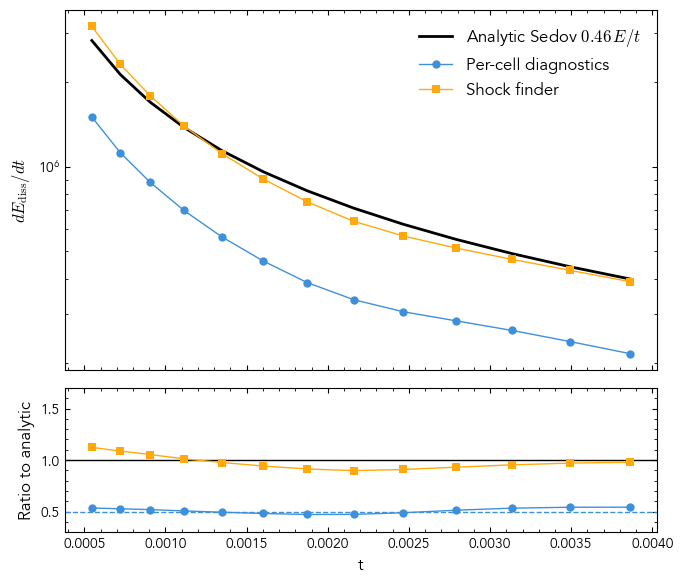

In [3]:
t = tab["time"]

for key, value in tab.items():
    tab[key] = value[t > 0.0005 * t.units]
t = tab["time"]

fig, (ax, axr) = plt.subplots(2, 1, figsize=(7, 6), sharex=True, height_ratios=[2.5, 1])

ax.plot(t, tab["diss_analytic"], "k-", lw=2, label="Analytic Sedov $0.46\\,E/t$")
ax.plot(t, tab["diss_rich"], "o-", label="Per-cell diagnostics")
ax.plot(t, tab["diss_sf"], "s-", label="Shock finder")
ax.set_ylabel(r"$dE_{\rm diss}/dt$")
ax.set_yscale("log")
ax.legend()

axr.axhline(1, color="k", lw=1)
axr.plot(t, tab["diss_rich"] / tab["diss_analytic"], "o-")
axr.plot(t, tab["diss_sf"] / tab["diss_analytic"], "s-")
axr.set_xlabel(r"t")
axr.set_ylabel("Ratio to analytic")
axr.set_ylim(0.3, 1.7)
axr.axhline(0.5, linestyle="--")

fig.tight_layout()
plt.show()

## Shock radius

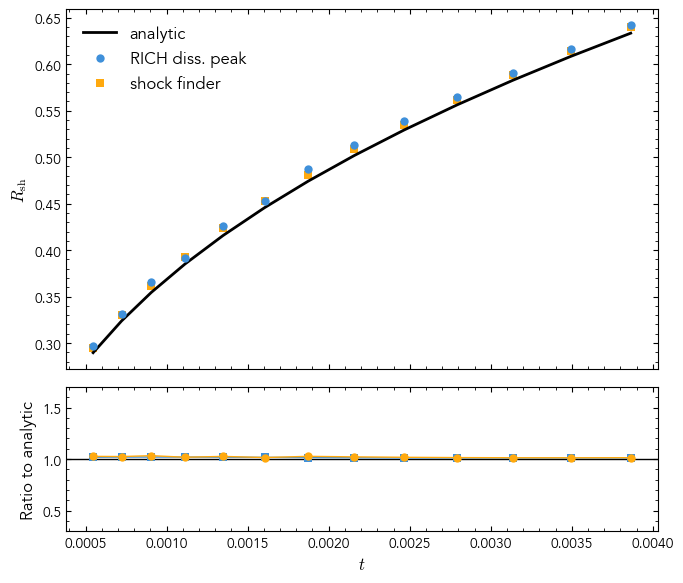

In [4]:
fig, (ax, axr) = plt.subplots(2, 1, figsize=(7, 6), sharex=True, height_ratios=[2.5, 1])

ax.plot(t, tab["R_analytic"], "k-", lw=2, label="analytic")
ax.plot(t, tab["R_rich"], "o", label="RICH diss. peak")
ax.plot(t, tab["R_sf"], "s", label="shock finder", zorder=0)
ax.set_ylabel(r"$R_{\rm sh}$")

axr.axhline(1, color="k", lw=1)
axr.plot(t, tab["R_sf"] / tab["R_analytic"], "s-")
axr.plot(t, tab["R_rich"] / tab["R_analytic"], "o-")
axr.set_xlabel(r"$t$")
axr.set_ylabel("Ratio to analytic")
axr.set_ylim(0.3, 1.7)

fig.tight_layout()
ax.legend()
fig.tight_layout()
plt.show()

## Mach number

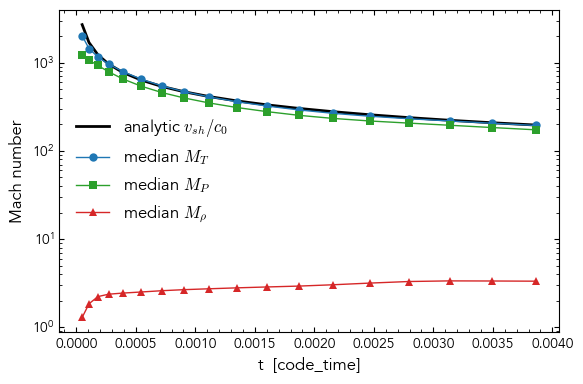

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, tab["mach_analytic"], "k-", lw=2, label="analytic $v_{sh}/c_0$")
ax.plot(t, tab["mach_T_med"], "o-", color="C0", label="median $M_T$")
ax.plot(t, tab["mach_P_med"], "s-", color="C2", label="median $M_P$")
ax.plot(t, tab["mach_rho_med"], "^-", color="C3", label="median $M_\\rho$")
ax.set_xlabel(f"t  [{t.units}]")
ax.set_ylabel("Mach number")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()
plt.show()

## Surface area

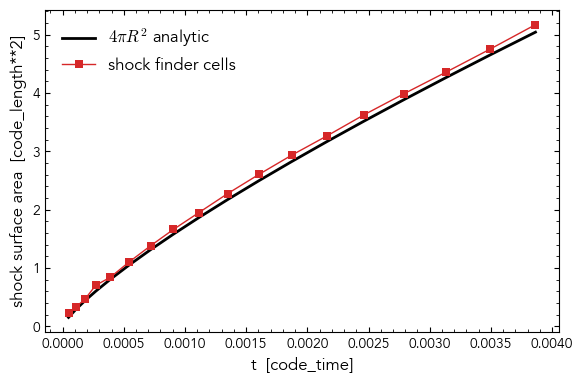

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, tab["area_analytic"], "k-", lw=2, label="$4\\pi R^2$ analytic")
ax.plot(t, tab["area_sf"], "s-", color="C3", label="shock finder cells")
ax.set_xlabel(f"t  [{t.units}]")
ax.set_ylabel(f"shock surface area  [{tab['area_sf'].units}]")
ax.legend()
fig.tight_layout()
plt.show()